In [1]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import random
from typing import Tuple, Literal, Optional, List, Union
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.signal import decimate
import matplotlib.pyplot as plt
import itertools
# For CNN/RNN
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer
)
from tensorflow.keras.optimizers import Adam


In [2]:

_CHUNK_RE = re.compile(r'_(\d+)\.h5$')          # capture the trailing “…_<chunk>.h5”

def _get_dataset_name(path: str) -> str:
    """Return the internal dataset name inside the HDF5 file."""
    return "_".join(os.path.basename(path).split('_')[:-1])
#C:\Users\odiee\OneDrive\Documents\24-25\Blok4\Deep Learning\Assignments\Assignment 2\Final Project data\Intra\train
def load_participant_arrays(participant_id: int, base_dir: str = "\train"):
    """
    Concatenate all chunks for every task of one participant and return
    four NumPy arrays in the order:
        rest, task_motor, task_story_math, task_working_memory

    Each array has shape (n_nodes, total_timepoints) or is None.
    """
    # buckets: task → list[(chunk_number, matrix)]
    buckets = {
        "rest":               [],
        "task_motor":         [],
        "task_story_math":    [],
        "task_working_memory": []
    }

    # find all relevant files, e.g. rest_105923_1.h5
    pattern = os.path.join(base_dir, f"*_{participant_id}_*.h5")
    for path in glob.glob(pattern):
        ds_name = _get_dataset_name(path)

        # identify task & chunk number
        task = next((t for t in buckets if ds_name.startswith(t)), None)
        if task is None:
            continue  # skip unrecognised file

        chunk_match = _CHUNK_RE.search(path)
        chunk_num = int(chunk_match.group(1)) if chunk_match else 0

        # load matrix
        with h5py.File(path, "r") as f:
            matrix = f[ds_name][()]        # (nodes, timepoints)

        buckets[task].append((chunk_num, matrix))

    # concatenate chunks for each task
    out = []
    for task, lst in buckets.items():
        if not lst:
            out.append(None)
            continue

        # sort by chunk number to keep temporal order
        lst.sort(key=lambda item: item[0])
        matrices = [m for _, m in lst]

        # sanity‑check dimensionality: all chunks must share the node axis size
        first_rows = matrices[0].shape[0]
        if not all(mat.shape[0] == first_rows for mat in matrices):
            raise ValueError(f"Inconsistent node counts in {task} chunks for participant {participant_id}")

        # concat along time axis (axis=1)
        out.append(np.concatenate(matrices, axis=1))

    return tuple(out)  # (rest, motor, story_math, working_memory)


# Training

## Intra Files

In [3]:
## TRAINING DATA ##

# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir="C:/Users/odiee/OneDrive/Documents/24-25/Blok4/Deep Learning/Assignments/Assignment 2/Final Project data/Intra/train")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Contra Files

In [4]:
## TRAINING DATA ##

# contra 1
participant_id_c1 = 113922

#contra 2
participant_id_c2 = 164636


rest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir="C:/Users/odiee/OneDrive/Documents/24-25/Blok4/Deep Learning/Assignments/Assignment 2/Final Project data/Cross/train")
rest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir="C:/Users/odiee/OneDrive/Documents/24-25/Blok4/Deep Learning/Assignments/Assignment 2/Final Project data/Cross/train")


print("Rest:", None if rest_c2 is None else rest_c2.shape)
print("Motor:", None if motor_c2 is None else motor_c2.shape)
print("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)
print("Working Memory:", None if wm_c2 is None else wm_c2.shape)

Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Pre-processing functions

### Intra

In [5]:
def preprocess_meg_data(
    arr: np.ndarray,
    *, #specify by keyword
    scaling: Literal["zscore", "minmax"] = "zscore",
    axis: int = 1,  # time axis
    downsample_method: Literal["slice", "decimate"] = "decimate",
    downsample_factor: Optional[int] = None,
    target_rate: Optional[int] = None,
    orig_rate: int = 2034,
    eps: float = 1e-12
) -> np.ndarray:
    """
    Scale and downsample MEG data.

    Parameters:
        arr: 2D MEG array [sensors x time]
        scaling: "zscore" or "minmax"
        axis: Axis along which to scale and downsample (default: time)
        downsample_method: "slice" or "decimate"
        downsample_factor: Optional integer downsampling factor
        target_rate: Optional new sample rate (alternative to factor)
        orig_rate: Original sample rate (used with target_rate)
        eps: Stability term

    Returns:
        Preprocessed MEG array [sensors x reduced_time]
    """
    # Scaling/Normalization
    if scaling == "zscore":
        means = arr.mean(axis=axis, keepdims=True)
        stds = arr.std(axis=axis, keepdims=True)
        arr = (arr - means) / (stds + eps)
    elif scaling == "minmax":
        mins = arr.min(axis=axis, keepdims=True)
        maxs = arr.max(axis=axis, keepdims=True)
        arr = (arr - mins) / (maxs - mins + eps)
    else:
        raise ValueError("scaling must be 'zscore' or 'minmax'")

    # Downsampling
    if downsample_factor is None:
        if target_rate is None:
            raise ValueError("Specify either downsample_factor or target_rate")
        downsample_factor = int(round(orig_rate / target_rate))

    if downsample_factor > 1:
        if downsample_method == "slice":
            slicer = [slice(None)] * arr.ndim
            slicer[axis] = slice(None, None, downsample_factor)
            arr = arr[tuple(slicer)]
        elif downsample_method == "decimate":
            arr = decimate(arr, downsample_factor, axis=axis, zero_phase=True)
        else:
            raise ValueError("downsample_method must be 'slice' or 'decimate'")

    return arr

### Contra

In [6]:
def preprocess_and_split_meg_data(
    arr: np.ndarray,
    *,  # keyword-only arguments
    scaling: Literal["zscore", "minmax"] = "zscore",
    axis: int = 1,
    downsample_method: Literal["slice", "decimate"] = "decimate",
    downsample_factor: Optional[int] = None,
    target_rate: Optional[int] = None,
    orig_rate: int = 2034,
    eps: float = 1e-12,
    return_params: bool = False
) -> Union[Tuple[np.ndarray, np.ndarray], Tuple[np.ndarray, np.ndarray, dict]]:
    """
    Normalize entire MEG array, split midway along time, and downsample each half.

    Parameters:
        arr: 2D MEG array [sensors x time] (concatenated)
        scaling: "zscore" or "minmax"
        axis: Axis along which to scale/split/downsample (default: time)
        downsample_method: "slice" or "decimate"
        downsample_factor: Optional integer downsampling factor
        target_rate: Optional new sample rate (alternative to factor)
        orig_rate: Original sample rate (used with target_rate)
        eps: Stability term
        return_params: If True, also return the normalization parameters

    Returns:
        Tuple of two preprocessed MEG arrays [sensors x reduced_time]
        Optionally, a dict of normalization parameters
    """
    params = {}

    # Normalize entire array
    if scaling == "zscore":
        means = arr.mean(axis=axis, keepdims=True)
        stds = arr.std(axis=axis, keepdims=True)
        arr = (arr - means) / (stds + eps)
        if return_params:
            params["scaling"] = "zscore"
            params["mean"] = means
            params["std"] = stds
    elif scaling == "minmax":
        mins = arr.min(axis=axis, keepdims=True)
        maxs = arr.max(axis=axis, keepdims=True)
        arr = (arr - mins) / (maxs - mins + eps)
        if return_params:
            params["scaling"] = "minmax"
            params["min"] = mins
            params["max"] = maxs
    else:
        raise ValueError("scaling must be 'zscore' or 'minmax'")

    # Split in half
    time_len = arr.shape[axis]
    mid = time_len // 2

    slicer1 = [slice(None)] * arr.ndim
    slicer2 = [slice(None)] * arr.ndim
    slicer1[axis] = slice(0, mid)
    slicer2[axis] = slice(mid, None)

    arr1 = arr[tuple(slicer1)]
    arr2 = arr[tuple(slicer2)]

    # Determine downsampling factor
    if downsample_factor is None:
        if target_rate is None:
            raise ValueError("Specify either downsample_factor or target_rate")
        downsample_factor = int(round(orig_rate / target_rate))

    # Downsample each half
    if downsample_factor > 1:
        if downsample_method == "slice":
            slicer = [slice(None)] * arr.ndim
            slicer[axis] = slice(None, None, downsample_factor)
            arr1 = arr1[tuple(slicer)]
            arr2 = arr2[tuple(slicer)]
        elif downsample_method == "decimate":
            arr1 = decimate(arr1, downsample_factor, axis=axis, zero_phase=True)
            arr2 = decimate(arr2, downsample_factor, axis=axis, zero_phase=True)
        else:
            raise ValueError("downsample_method must be 'slice' or 'decimate'")

    if return_params:
        params["downsample_factor"] = downsample_factor
        params["downsample_method"] = downsample_method
        return arr1, arr2, params

    return arr1, arr2


In [15]:
def cossim_cluster_multi_task(task_list, n_clusters=5):
    """
    output:
        sorted_indices: Indices that reorder sensors by cluster.
        labels: Cluster labels for each sensor.
        avg_sim_matrix: Averaged cosine similarity matrix.
    """

    # cosine similarity matrix for each task
    sim_matrices = []
    for task in task_list:
        sim = cosine_similarity(task)
        sim_matrices.append(sim)

    # avg similarity matrices
    avg_sim_matrix = np.mean(sim_matrices, axis=0)
    avg_dist_matrix = 1 - avg_sim_matrix

    # clustering
    clustering = AgglomerativeClustering(
        metric='precomputed',
        linkage='average',
        n_clusters=n_clusters
    )
    labels = clustering.fit_predict(avg_dist_matrix)

    # reorder indices
    sorted_indices = np.argsort(labels)

    return sorted_indices, labels, avg_sim_matrix


In [35]:
def combine_cluster_order(labels1, labels2, threshold=2, n_clusters=5):
    n_sensors = len(labels1)
    combined_labels = -1 * np.ones(n_sensors, dtype=int)
    ordered_indices = []

    for cluster_id in range(n_clusters):
        mask1 = labels1 == cluster_id
        mask2 = labels2 == cluster_id

        if threshold == 1:  # union
            combined_mask = mask1 | mask2
        elif threshold == 2:  # intersection
            combined_mask = mask1 & mask2
        else:
            raise ValueError("Threshold must be 1 (union) or 2 (intersection)")

        indices = np.where(combined_mask)[0]
        #print("Indices: ", len(indices))
        combined_labels[indices] = cluster_id
        ordered_indices.extend(indices.tolist())
        

    # Remove duplicates while preserving order
    seen = set()
    ordered_indices = [x for x in ordered_indices if not (x in seen or seen.add(x))]
    print("\n Ordered indices: ", len(ordered_indices))
    return np.array(ordered_indices), combined_labels


### Training Intra

In [25]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets = [
    preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
    for data in datasets
]

# clustering using averaged cosine similarity
sensor_order, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels




In [26]:
print(preprocessed_datasets[0].shape)

(248, 8906)


In [21]:
# maybe not the most efficient way oops
rest_data = reordered_data_dict["reordered_data_rest"]
rest_sensor_order = sensor_order_dict["sensor_order_rest"]
rest_clusters = cluster_labels_dict["cluster_labels_rest"]

motor_data = reordered_data_dict["reordered_data_motor"]
motor_sensor_order = sensor_order_dict["sensor_order_motor"]
motor_clusters = cluster_labels_dict["cluster_labels_motor"]

story_math_data = reordered_data_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_order_dict["sensor_order_story_math"]
story_math_clusters = cluster_labels_dict["cluster_labels_story_math"]

wm_data = reordered_data_dict["reordered_data_wm"]
wm_sensor_order = sensor_order_dict["sensor_order_wm"]
wm_clusters = cluster_labels_dict["cluster_labels_wm"]


### Contra Train data

In [8]:
datasets_c1 = [rest_c1, motor_c1, story_math_c1, wm_c1]
datasets_c2 = [rest_c2, motor_c2, story_math_c2, wm_c2]
# concatenate 2 persons, think of different approaches
datasets_contra = [np.concatenate((d1, d2), axis=1) for d1, d2 in zip(datasets_c1, datasets_c2)]
#task_names_c1 = ["rest_c1", "motor_c1", "story_math_c1", "wm_c1"]
#task_names_c2 = ["rest_c2", "motor_c2", "story_math_c2", "wm_c2"]
task_names = ["rest", "motor", "story_math", "wm"]

In [9]:
print(datasets_contra[1].shape)

(248, 569984)


In [10]:
# preprocessing all datasets
split_datasets_contra_with_params = [
    preprocess_and_split_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034,
        return_params=True
    )
    for data in datasets_contra
]

# unpack separately
split1_contra, split2_contra, norm_params_contra = zip(*split_datasets_contra_with_params)

In [11]:
print(split1_contra[1].shape)

(248, 8906)


In [12]:
print(len(norm_params_contra))

4


In [37]:
reordered_data_dict_contra = {}
sensor_order_dict_contra = {}
cluster_labels_dict_contra = {}

# Cluster across all 4 tasks per participant
_, labels1, _ = cossim_cluster_multi_task(split1_contra)  # list of 4 datasets
_, labels2, _ = cossim_cluster_multi_task(split2_contra)

# Get sensor order and cluster labels
sensor_order, cluster_labels = combine_cluster_order(
    labels1,
    labels2,
    threshold=1,
    n_clusters=5
)

# Reorder all datasets individually
for data1, data2, name in zip(split1_contra, split2_contra, task_names):
    reordered1 = data1[sensor_order, :]
    reordered2 = data2[sensor_order, :]

    reordered_data_dict_contra[f"reordered_data_{name}_p1"] = reordered1
    reordered_data_dict_contra[f"reordered_data_{name}_p2"] = reordered2
    sensor_order_dict_contra[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict_contra[f"cluster_labels_{name}"] = cluster_labels



 Ordered indices:  248


In [38]:
print(reordered_data_dict_contra.keys())

dict_keys(['reordered_data_rest_p1', 'reordered_data_rest_p2', 'reordered_data_motor_p1', 'reordered_data_motor_p2', 'reordered_data_story_math_p1', 'reordered_data_story_math_p2', 'reordered_data_wm_p1', 'reordered_data_wm_p2'])


In [39]:
testy = reordered_data_dict_contra["reordered_data_rest_p1"]
print(testy.shape)

(248, 8906)


In [ ]:
# Contra person 1 & 2
'''
rest_data_contra = reordered_data_dict_contra["reordered_data_rest"]
rest_sensor_order_contra = sensor_order_dict_contra["sensor_order_rest"]
rest_clusters_contra = cluster_labels_dict_contra["cluster_labels_rest"]

motor_data_contra = reordered_data_dict_contra["reordered_data_motor"]
motor_sensor_order_contra = sensor_order_dict_contra["sensor_order_motor"]
motor_clusters_contra = cluster_labels_dict_contra["cluster_labels_motor"]

story_math_data_contra = reordered_data_dict_contra["reordered_data_story_math"]
story_math_sensor_order_contra = sensor_order_dict_contra["sensor_order_story_math"]
story_math_clusters_contra = cluster_labels_dict_contra["cluster_labels_story_math"]

wm_data_contra = reordered_data_dict_contra["reordered_data_wm"]
wm_sensor_order_contra = sensor_order_dict_contra["sensor_order_wm"]
wm_clusters_contra = cluster_labels_dict_contra["cluster_labels_wm"]'''

### Data Visualization

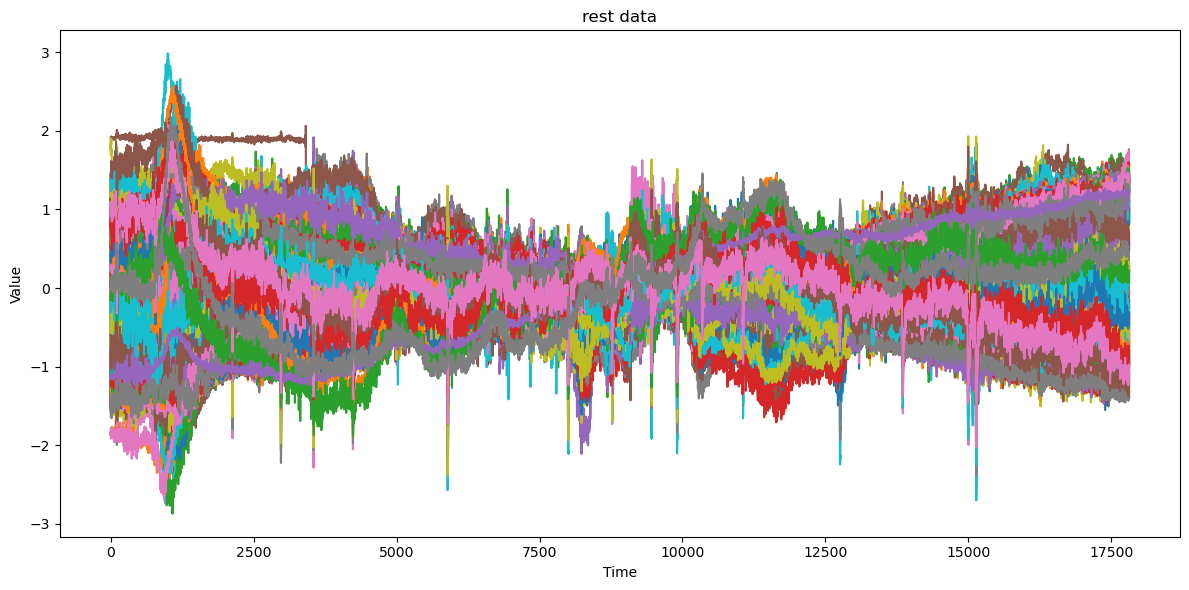

In [23]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(rest_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("rest data")
plt.tight_layout()
plt.show()

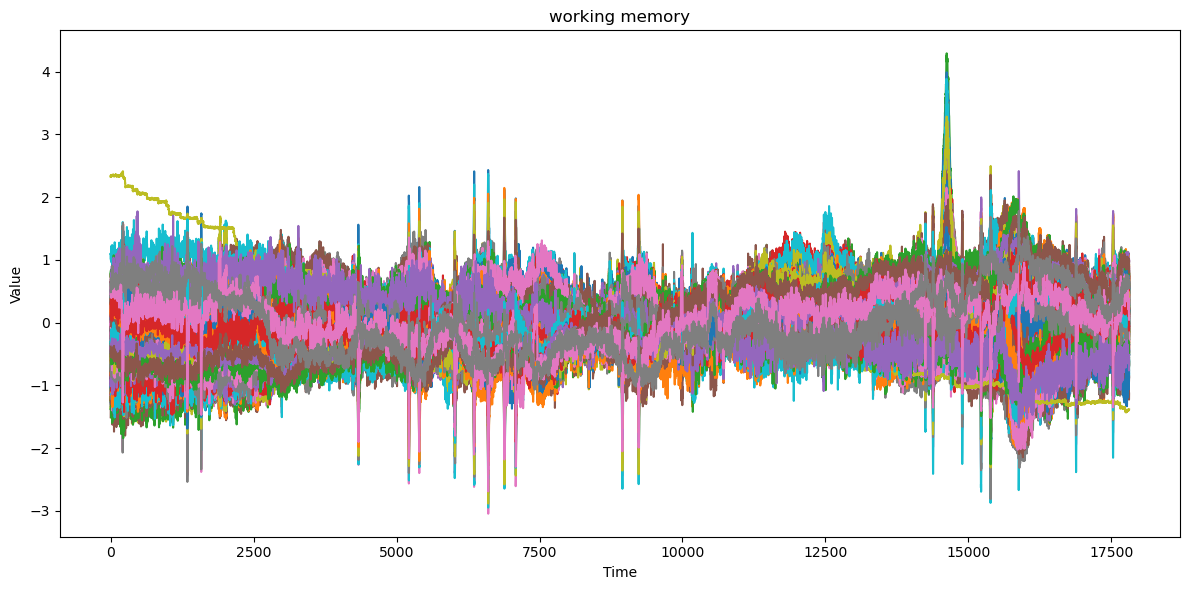

In [24]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(wm_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("working memory")
plt.tight_layout()
plt.show()

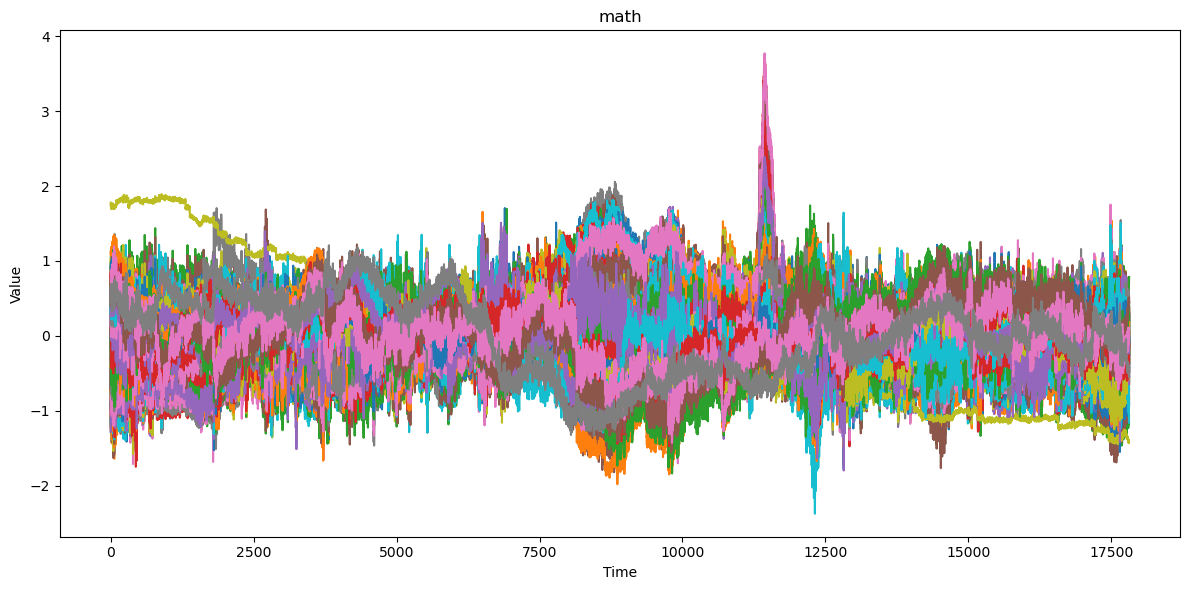

In [21]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(story_math_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("math")
plt.tight_layout()
plt.show()

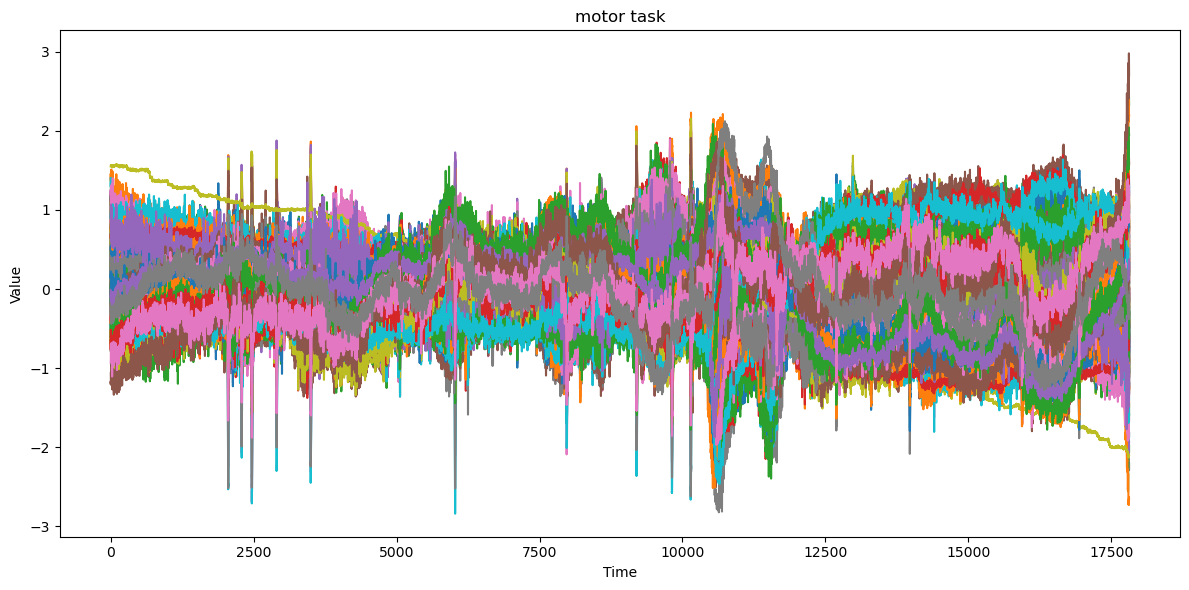

In [25]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(motor_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("motor task")
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Optional, List

def plot_avg_sensor_similarity(
    sim_matrix: np.ndarray,
    sensor_order: Optional[np.ndarray] = None,
    cluster_labels: Optional[np.ndarray] = None,
    figsize: tuple = (10, 8),
    title: str = "Average Sensor Similarity Across Tasks",
    cmap: str = "viridis"
):
    """
        sim_matrix: 2D numpy array [sensors x sensors], average cosine similarity matrix.
        sensor_order: array of reordered sensor indices.
        cluster_labels: array of cluster labels (used to mark cluster boundaries).

    """
    # Apply sensor reordering if provided
    if sensor_order is not None:
        sim_matrix = sim_matrix[np.ix_(sensor_order, sensor_order)]
        if cluster_labels is not None:
            cluster_labels = np.array(cluster_labels)[sensor_order]

    plt.figure(figsize=figsize)
    sns.heatmap(sim_matrix, cmap=cmap, square=True, cbar=True)
    plt.title(title)
    plt.xlabel("Sensors")
    plt.ylabel("Sensors")

    # Optional: draw lines between clusters
    if cluster_labels is not None:
        boundaries = []
        last_label = cluster_labels[0]
        for i, lbl in enumerate(cluster_labels):
            if lbl != last_label:
                boundaries.append(i)
                last_label = lbl
        for b in boundaries:
            plt.axhline(b, color='white', lw=1)
            plt.axvline(b, color='white', lw=1)

    plt.tight_layout()
    plt.show()


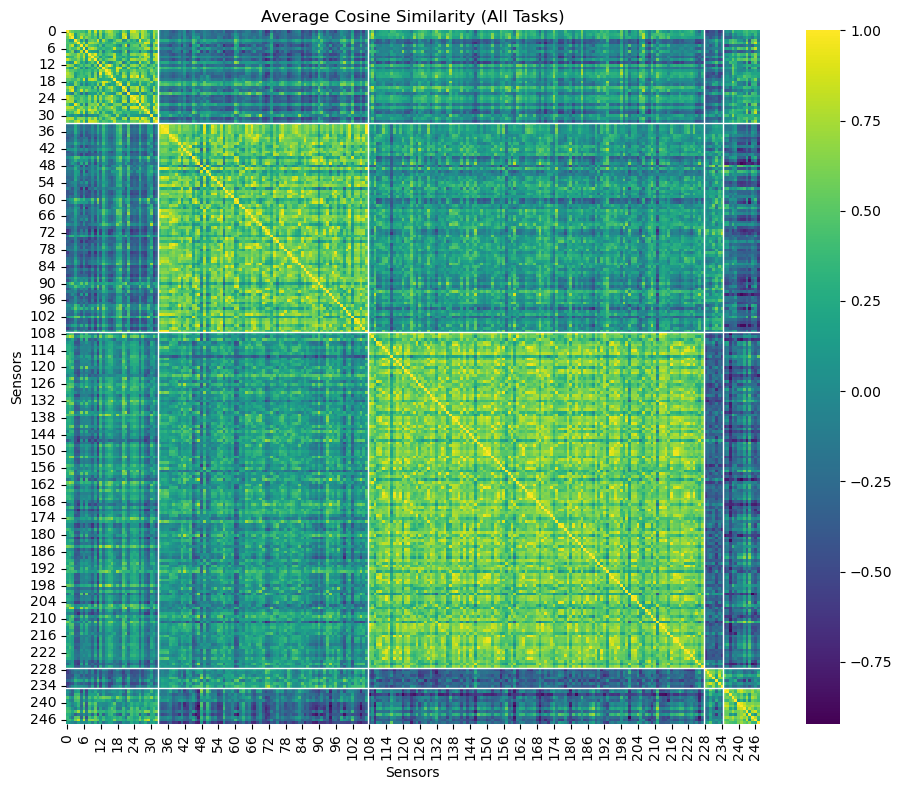

In [40]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)


### Simple FFN

In [ ]:
def prepare_ffnn_data(X):
    """
    X shape: (samples, sequence_length, height, width)
    Returns shape: (samples, sequence_length) after spatial average
    """
    return X.mean(axis=(2, 3))  # average over height and width

# Prepare data
X_train_ffnn = prepare_ffnn_data(X_train)
X_val_ffnn = prepare_ffnn_data(X_val)
X_all_ffnn = prepare_ffnn_data(X_all)

# Build FFNN model
def build_ffnn(input_shape, dense_units=128, dropout_rate=0.3, num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate and compile
ffnn_model = build_ffnn(input_shape=(X_train_ffnn.shape[1],))
ffnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
ffnn_model.fit(
    X_train_ffnn, y_train,
    validation_data=(X_val_ffnn, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)


## Create training/validation sets for models


### No subchunk prediction

In [46]:
def make_sequences(
    data, 
    time_per_snapshot=32,       # e.g., 0.5s at 50 Hz
    sequence_length=10, 
    overlap=0.3                 # 0.5 means 50% overlap
):
    """
    Create sequences of MEG data snapshots with optional overlap.
    """
    sensors, total_time = data.shape
    step = int(time_per_snapshot * sequence_length * (1 - overlap))
    
    # Ensure at least one step forward
    step = max(1, step)

    sequences = []
    for start in range(0, total_time - time_per_snapshot * sequence_length + 1, step):
        seq = np.zeros((sequence_length, sensors, time_per_snapshot))
        for j in range(sequence_length):
            snap_start = start + j * time_per_snapshot
            snap_end = snap_start + time_per_snapshot
            seq[j] = data[:, snap_start:snap_end]
        sequences.append(seq)

    return np.array(sequences)


In [ ]:
time_per_snapshot = 32       # 1s per snapshot isince it's sampled at 128 Hz
sequence_length = 6          # 10 snapshots per sequence (10s)
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

In [ ]:

# create input sequences
X_rest = make_sequences(rest_data, time_per_snapshot, sequence_length)
X_motor = make_sequences(motor_data, time_per_snapshot, sequence_length)
X_story = make_sequences(story_math_data, time_per_snapshot, sequence_length)
X_wm = make_sequences(wm_data, time_per_snapshot, sequence_length)

# output labels
y_rest = np.full((X_rest.shape[0],), label_map["rest"])
y_motor = np.full((X_motor.shape[0],), label_map["motor"])
y_story = np.full((X_story.shape[0],), label_map["story_math"])
y_wm = np.full((X_wm.shape[0],), label_map["wm"])

In [ ]:
# combining all task data
X_all = np.concatenate([X_rest, X_motor, X_story, X_wm], axis=0)
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm], axis=0)

# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

### Subchunk prediction

In [41]:
def make_sequences_with_ids(
    data_list,
    labels_list,
    time_per_snapshot=32, 
    sequence_length=10, 
    overlap=0.3  
):
    """
    Creates subchunk sequences for a list of MEG sequences with labels.
    
    Returns:
        X: np.array of shape (num_subchunks, sequence_length, sensors, time_per_snapshot)
        y: np.array of shape (num_subchunks,) — label for each subchunk
        ids: np.array of shape (num_subchunks,) — sequence ID for grouping later
    """
    X = []
    y = []
    ids = []
    seq_counter = 0

    for data, label in zip(data_list, labels_list):
        # data shape: (sensors, total_time)
        sensors, total_time = data.shape
        step = int(time_per_snapshot * sequence_length * (1 - overlap))
        step = max(1, step)

        for start in range(0, total_time - time_per_snapshot * sequence_length + 1, step):
            chunk = np.zeros((sequence_length, sensors, time_per_snapshot))
            for j in range(sequence_length):
                snap_start = start + j * time_per_snapshot
                snap_end = snap_start + time_per_snapshot
                chunk[j] = data[:, snap_start:snap_end]
            X.append(chunk)
            y.append(label)
            ids.append(seq_counter)  # group ID for later aggregation

        seq_counter += 1

    return np.array(X), np.array(y), np.array(ids)

### Intra

In [ ]:
time_per_snapshot = 32       # 1s per snapshot isince it's sampled at 128 Hz
sequence_length = 6          # 10 snapshots per sequence (10s)
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# Prepare inputs
data_list = [rest_data, motor_data, story_math_data, wm_data]
labels_list = [label_map["rest"], label_map["motor"], label_map["story_math"], label_map["wm"]]

# Generate sequences
X_all, y_all, ids_all = make_sequences_with_ids(
    data_list=data_list,
    labels_list=labels_list,
    time_per_snapshot=32,
    sequence_length=6
)

# train/val split
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_all, y_all, ids_all, test_size=0.2, random_state=42, stratify=y_all
)

In [ ]:
from collections import Counter
def aggregate_predictions(predictions, ids):
    """
    Aggregate predictions using majority vote per group ID.
    
    Args:
        predictions: np.array of predicted class indices
        ids: sequence group IDs for each prediction
    
    Returns:
        Dict of {sequence_id: final_prediction}
    """
    final_preds = {}
    for seq_id in np.unique(ids):
        seq_preds = predictions[ids == seq_id]
        majority = Counter(seq_preds).most_common(1)[0][0]
        final_preds[seq_id] = majority
    return final_preds


### Contra

In [ ]:
label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

data_list = []
labels_list = []

for condition in ['rest', 'motor', 'story_math', 'wm']:
    data_p1 = reordered_data_dict_contra[f'reordered_data_{condition}_p1']
    data_p2 = reordered_data_dict_contra[f'reordered_data_{condition}_p2']

    label = label_map[condition]

    # Append data and matching labels
    data_list.extend([data_p1, data_p2])
    labels_list.extend([label, label])

print(f"Data count: {len(data_list)}")
print(f"Labels count: {len(labels_list)}")
print(f"Shape example: {data_list[0].shape if data_list else 'No data'}")


X_all, y_all, ids_all = make_sequences_with_ids(
    data_list=data_list,
    labels_list=labels_list,
    time_per_snapshot=32,
    sequence_length=6
)

# Train-validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_all, y_all, ids_all, test_size=0.2, random_state=42, stratify=y_all
)


Data count: 8
Labels count: 8
Shape example: (248, 8906)


In [45]:
print(X_train.shape)
print(y_train.shape)

(422, 6, 248, 32)
(422,)


### build/train single model

In [46]:
# CNN branch to encode a snapshot (spatial sensor pattern)
def build_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)  # shape: (sensors, time_per_snapshot)
    x = layers.Conv1D(32, kernel_size=5, activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)  # Output shape: (64,)
    model = models.Model(inputs, x, name='cnn_encoder')
    return model

# Combine CNN into RNN for full sequence classification
def build_cnn_rnn(cnn_encoder, snapshot_shape, sequence_length, num_classes=4):
    """
    snapshot_shape: tuple like (sensors, time_per_snapshot)
    sequence_length: number of snapshots per sequence
    """
    inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)  # shape: (seq_len, sensors, time_per_snapshot)
    
    # Apply CNN to each snapshot in the sequence
    encoded = layers.TimeDistributed(cnn_encoder)(inputs)  # shape: (batch, seq_len, features)
    
    # Temporal modeling
    x = layers.GRU(128, return_sequences=False)(encoded)  # shape: (batch, 128)
    x = layers.Dense(64, activation='relu')(x)
    
    # Multiclass output
    output = layers.Dense(num_classes, activation='softmax')(x)  # shape: (batch, 4)
    
    model = models.Model(inputs, output, name='cnn_rnn_model')
    return model


In [49]:

cnn_encoder = build_cnn(input_shape=(X_all.shape[2], X_all.shape[3]))  # (sensors, time_per_snapshot)
model = build_cnn_rnn(cnn_encoder, snapshot_shape=(X_all.shape[2], X_all.shape[3]), sequence_length=X_all.shape[1], num_classes=4)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train
intra_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=16)


Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.2663 - loss: 1.3703 - val_accuracy: 0.4434 - val_loss: 1.3354
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4634 - loss: 1.2668 - val_accuracy: 0.5755 - val_loss: 1.0854
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5507 - loss: 1.0781 - val_accuracy: 0.5377 - val_loss: 1.0881
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5962 - loss: 0.9401 - val_accuracy: 0.5377 - val_loss: 0.8984
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5847 - loss: 0.9024 - val_accuracy: 0.7264 - val_loss: 0.6499
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7083 - loss: 0.7004 - val_accuracy: 0.6698 - val_loss: 0.8419
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6933 - loss: 0.7333 - val_accuracy: 0.7925 - val_loss: 0.5112
Epoch 8/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7900 - loss: 0.5714 - val_accuracy: 0.7925 - 

In [50]:

def plot_training_history(history, metrics=['loss', 'accuracy']):
    """
    Plot training and validation metrics from Keras history.

    Parameters:
        history: Keras History object (e.g., returned by model.fit)
        metrics: List of metrics to plot (default: ['loss', 'accuracy'])
    """
    if not hasattr(history, 'history'):
        raise ValueError("Expected a Keras History object")

    history_dict = history.history
    epochs = range(1, len(history_dict[metrics[0]]) + 1)

    for metric in metrics:
        plt.figure(figsize=(8, 4))
        plt.plot(epochs, history_dict[metric], 'b-', label=f'Train {metric}')
        val_metric = f'val_{metric}'
        if val_metric in history_dict:
            plt.plot(epochs, history_dict[val_metric], 'r--', label=f'Val {metric}')
        plt.title(f'{metric.capitalize()} over Epochs')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()


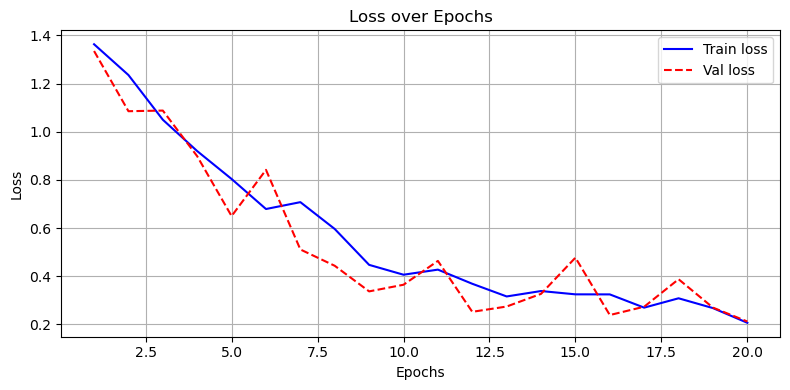

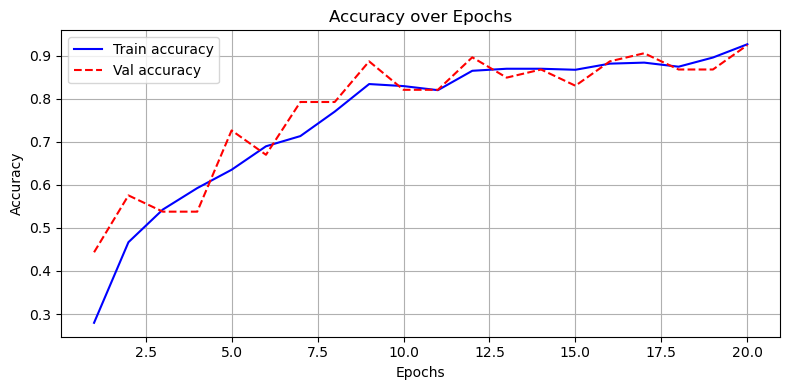

In [51]:
plot_training_history(intra_history, metrics=['loss', 'accuracy'])


## Grid hyperparameter search

In [32]:
from collections import defaultdict, Counter

# gridserach params
cnn_filters = [16, 32, 64]
kernel_sizes = [3, 5]
gru_units = [32, 64, 96, 128]
dense_sizes = [64, 128]
dropout_rates = [0.2, 0.3, 0.4]
learning_rates = [1e-3, 5e-4, 1e-4]
bidirectional_opts = [True, False]
batch_sizes = [8, 16]
epochs = [40, 50]


param_grid = list(itertools.product(
    cnn_filters, kernel_sizes, gru_units, dense_sizes,
    dropout_rates, learning_rates, bidirectional_opts,
    batch_sizes, epochs
))

n_trials = 30
random.seed(42)
sampled_configs = random.sample(param_grid, n_trials)

results = []

# function for majority vote calculation
def majority_vote(preds, ids):
    grouped = defaultdict(list)
    for p, i in zip(preds, ids):
        grouped[i].append(p)
    return {i: Counter(grouped[i]).most_common(1)[0][0] for i in grouped}

# train loop
for cnn_f, ksize, gru_u, dense_s, drop_r, lr, bi, batch_s, epoch_n in sampled_configs:
    print(f"\nTesting config: CNN={cnn_f}, KSize={ksize}, GRU={gru_u}, Dense={dense_s}, Dropout={drop_r}, LR={lr}, BiGRU={bi}, Batch={batch_s}, Epochs={epoch_n}")

    def build_cnn(input_shape):
        inputs = layers.Input(shape=input_shape)
        x = layers.Conv1D(cnn_f, kernel_size=ksize, activation='relu')(inputs)
        x = layers.MaxPooling1D(pool_size=2)(x)
        x = layers.Conv1D(cnn_f * 2, kernel_size=3, activation='relu')(x)
        x = layers.GlobalAveragePooling1D()(x)
        return models.Model(inputs, x)

    def build_model(snapshot_shape, sequence_length, num_classes=4):
        cnn_encoder = build_cnn(snapshot_shape)
        inputs = layers.Input(shape=(sequence_length,) + snapshot_shape)
        x = layers.TimeDistributed(cnn_encoder)(inputs)
        if bi:
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=True))(x)
            x = layers.Bidirectional(layers.GRU(gru_u, return_sequences=False))(x)
        else:
            x = layers.GRU(gru_u, return_sequences=True)(x)
            x = layers.GRU(gru_u, return_sequences=True)(x)
            x = layers.GRU(gru_u, return_sequences=False)(x)
        x = layers.Dropout(drop_r)(x)
        x = layers.Dense(dense_s, activation='relu')(x)
        x = layers.Dropout(drop_r)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        return models.Model(inputs, outputs)

    model = build_model(snapshot_shape=(X_all.shape[2], X_all.shape[3]), sequence_length=sequence_length)
    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epoch_n, batch_size=batch_s, verbose=0)
    history_data = history.history

    # subchunk-level accuracy
    best_val_acc = max(history_data['val_accuracy'])
    best_val_loss = min(history_data['val_loss'])

    # subchunk-level predictions
    subchunk_preds = np.argmax(model.predict(X_val, batch_size=batch_s), axis=1)

    # aggregated sequence-level predictions
    aggregated_preds = majority_vote(subchunk_preds, ids_val)
    true_labels = {i: y_val[np.where(ids_val == i)[0][0]] for i in aggregated_preds}
    aggregated_acc = np.mean([aggregated_preds[i] == true_labels[i] for i in aggregated_preds])

    results.append({
        'val_accuracy': best_val_acc,
        'val_loss': best_val_loss,
        'agg_accuracy': aggregated_acc,
        'params': {
            'cnn_filters': cnn_f, 'kernel_size': ksize, 'gru_units': gru_u,
            'dense_size': dense_s, 'dropout': drop_r, 'learning_rate': lr,
            'bidirectional': bi, 'batch_size': batch_s, 'epochs': epoch_n
        },
        'history': history_data
    })

# --- Sort by both accuracy and loss ---
results.sort(key=lambda x: (-x['agg_accuracy'], x['val_loss']))

# --- Top 5 ---
print("\nTop 5 Configurations (by aggregated accuracy and loss):")
for r in results[:5]:
    print(f"Subchunk Val Acc: {r['val_accuracy']:.4f}, Seq Acc: {r['agg_accuracy']:.4f}, Val Loss: {r['val_loss']:.4f}, Params: {r['params']}")



Testing config: CNN=64, KSize=3, GRU=96, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=16, Epochs=50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step

Testing config: CNN=16, KSize=3, GRU=128, Dense=64, Dropout=0.3, LR=0.001, BiGRU=True, Batch=8, Epochs=40
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 285ms/step

Testing config: CNN=16, KSize=3, GRU=32, Dense=128, Dropout=0.3, LR=0.001, BiGRU=False, Batch=16, Epochs=40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step

Testing config: CNN=64, KSize=5, GRU=64, Dense=64, Dropout=0.2, LR=0.0005, BiGRU=False, Batch=8, Epochs=50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step

Testing config: CNN=16, KSize=5, GRU=128, Dense=128, Dropout=0.3, LR=0.0001, BiGRU=False, Batch=16, Epochs=40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 622ms/step

Testing config: CNN=16, KSize=5, GRU=96, Dense=128, Dropout=0.4, LR=0.0001, BiGRU=True, Batch=16, Epochs=50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 537ms/step

Testing config: CNN=16, KSize=5, GRU=96, Dense=64, Dropout=0.4, LR=0.001, BiGRU=True, Batch=16, Epochs=40
4/4 ━━━━━━━

Best Configuration:
  cnn_filters: 32
  kernel_size: 5
  gru_units: 128
  dense_size: 128
  dropout: 0.2
  learning_rate: 0.001
  bidirectional: True
  batch_size: 8
  epochs: 40


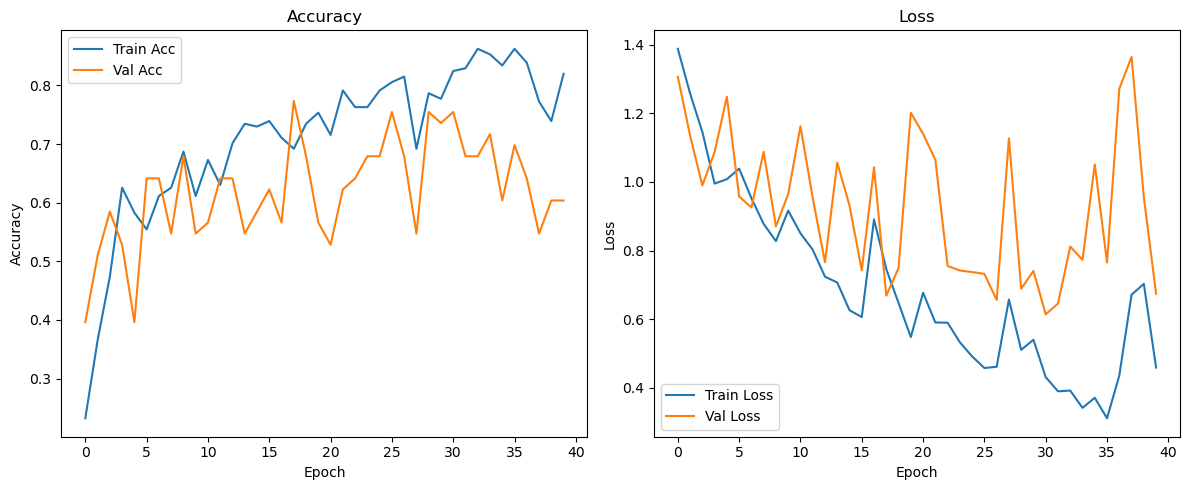

In [34]:
# Sort by best validation accuracy
results.sort(key=lambda x: x['val_accuracy'], reverse=True)

# Get the best result
best_result = results[0]
best_history = best_result['history']

# Print best config
print("Best Configuration:")
for k, v in best_result['params'].items():
    print(f"  {k}: {v}")

# Plotting training and validation accuracy/loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(best_history['accuracy'], label='Train Acc')
plt.plot(best_history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(best_history['loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Testing

## Intra Testing

## Contra Testing